# Live Inference on an Epoched Stream — Validation Notebook

Runs the **real online inference path** (`OnlinePreprocessor` + `LiveInferenceEngine`)
on a selected recording, then epochs the resulting probability stream by marker so
we can see, per decoder:

- the prediction time-course for **individual epochs**, and
- the **average prediction per marker** (the "does the inference make sense?" view).

**Method.** The whole recording is pushed through the online pipeline in micro-batches
with *persistent* causal filter state — exactly like `StreamWorker` — producing a
continuous 100 Hz probability stream. That stream is then cut into trigger-locked
epochs. No LSL / QThread is involved, so it is deterministic and fast, and filter
state stays continuous across the whole recording (no per-epoch warm-up artifact).

**Caveats**
1. **Leakage.** Running on the *training* recording yields optimistically-high
   probabilities. This is fine for a sanity check ("the decoder fires for the right
   marker"), but it is **not** a performance number — cross-validated AUC is.
2. **Single-timepoint model, swept over time.** Each decoder is a *spatial* classifier
   trained at one timepoint and applied at every 100 Hz sample; that sweep is what
   produces the per-epoch P(t) curve.
3. **Channel feed.** EEG is fed as **64 channels (EMG dropped) + trigger**, matching
   `scripts/replay_vhdr_to_lsl.py`. Offline computes `eeg_chunk_indices` on the
   EMG-*included* array, so there is an alignment assumption here (EMG last) — see the
   GH issue. Cell 4 asserts the alignment and fails loudly if it does not hold.
4. **Profile-driven.** `CONFIG_PATH`, `ARTIFACT_PATH`, and `RECORDING_DIR` all come
   from one debug profile (cell below, `PROFILE`), so the config, trained artifact, and
   replayed recording always match. Seed a profile with
   `scripts/demo_seed_debug_snapshots.py`.

*Validation only — not part of the app.*

In [70]:
import sys
import re
from collections import Counter
from pathlib import Path

# Walk up to find src/, regardless of where Jupyter was launched from.
_search = Path().resolve()
REPO_ROOT = None
while _search != _search.parent:
    if (_search / "src" / "backend").exists():
        REPO_ROOT = _search
        if str(_search / "src") not in sys.path:
            sys.path.insert(0, str(_search / "src"))
        break
    _search = _search.parent

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt
import numpy as np
import mne
mne.set_log_level("ERROR")

from backend.core.settings_manager import SettingsManager
from backend.online_phase.artifact_loader import load_decoder_pipeline_artifact
from backend.online_phase.online_preprocessor import OnlinePreprocessor
from backend.online_phase.live_inference import LiveInferenceEngine

print("repo root:", REPO_ROOT)

repo root: /home/itaip/projects/live-reactivation-decoder


---
## Configuration

In [71]:
from frontend.debug.profiles import load_profile

# ── Debug profile ─────────────────────────────────────────────────────────
# Everything (config, trained artifact, and the exact recording it was built
# from) is resolved from one named profile under debug_snapshots/<PROFILE>/.
# Seed it with:
#   python -m scripts.demo_seed_debug_snapshots --profile fl_logistic \
#       --config experiment_config.full.yaml --data data/split/functional_localizer
PROFILE = "fl_logistic_late"

_profile = load_profile(PROFILE, root=REPO_ROOT / "debug_snapshots")
CONFIG_PATH   = _profile.config_path        # config copied into the profile dir
ARTIFACT_PATH = _profile.pipeline_path      # models/decoder_pipeline.joblib
RECORDING_DIR = _profile.raw_data_dir       # the recording the artifact was trained on
if not RECORDING_DIR.is_absolute():
    RECORDING_DIR = (REPO_ROOT / RECORDING_DIR).resolve()

# Quick-run crop: process only the first N seconds. None = full recording.
# Keep <= the recording length (the FL localizer is ~3267 s).
MAX_SECONDS = None

# Markers to epoch & display. None = auto: every decoder's positive label.
MARKERS_OF_INTEREST = None

# Mirror StreamWorker's default micro-batch so we exercise the same batching path.
BATCH_SIZE_SAMPLES = 40

print("profile      :", _profile.name)
print("config       :", CONFIG_PATH)
print("artifact     :", ARTIFACT_PATH)
print("recording dir:", RECORDING_DIR)

profile      : fl_logistic_late
config       : /home/itaip/projects/live-reactivation-decoder/debug_snapshots/fl_logistic_late/experiment_config.yaml
artifact     : /home/itaip/projects/live-reactivation-decoder/debug_snapshots/fl_logistic_late/models/decoder_pipeline.joblib
recording dir: /home/itaip/projects/live-reactivation-decoder/data/split/functional_localizer


---
## Load settings + trained artifact, build the live engine

In [72]:
settings         = SettingsManager(CONFIG_PATH)
prepro_settings  = settings.get_preprocessing_params()
decoder_settings = settings.get_decoder_settings()
event_mapping    = settings.get_event_mapping()        # name -> trigger code
name_by_code     = {v: k for k, v in event_mapping.items()}

# Map each decoder to its positive marker (for the per-decoder individual-epoch view).
task_pos_marker = {t["name"]: t["pos_labels"][0] for t in decoder_settings["tasks"]}

# Auto-derive markers of interest from the decoders' positive labels if unset.
if MARKERS_OF_INTEREST is None:
    MARKERS_OF_INTEREST = list(dict.fromkeys(
        lbl for t in decoder_settings["tasks"] for lbl in t["pos_labels"]
    ))

artifact = load_decoder_pipeline_artifact(ARTIFACT_PATH)
preproc  = OnlinePreprocessor(prepro_settings, artifact.online_state)
engine   = LiveInferenceEngine(artifact.models, artifact.metadata)

eci         = list(artifact.online_state["eeg_chunk_indices"])
# Per-decoder training timepoints (Fix 4). For older artifacts that only store a
# single shared `decoding_timepoint`, task_tp() falls back to it for every task.
default_tp  = artifact.metadata.get("decoding_timepoint")
tp_by_task  = artifact.metadata.get("decoding_timepoints") or {}

def task_tp(task):
    """The timepoint this decoder was trained at (per-task if present, else shared)."""
    return tp_by_task.get(task, default_tp)

print("resample_filter_stage :", prepro_settings.get("resample_filter_stage"))
print("lowpass method        :", prepro_settings["lowpass"].get("method"))
print("tasks (models)        :", list(artifact.models.keys()))
print("markers of interest   :", MARKERS_OF_INTEREST)
print("feature_width         :", engine.feature_width)
print("preproc.n_channels    :", preproc.n_channels)
print("len(eeg_chunk_indices):", len(eci), "| max index:", max(eci))
print("trained timepoint(s)  :", tp_by_task if tp_by_task else f"{default_tp} (shared)")

assert engine.feature_width == preproc.n_channels, (
    "feature_width vs preproc channel-count mismatch"
)

resample_filter_stage : late
lowpass method        : iir
tasks (models)        : ['red decoder', 'green decoder', 'yellow decoder', 'living_room decoder', 'bathroom decoder', 'kitchen decoder']
markers of interest   : ['red', 'green', 'yellow', 'living_room', 'bathroom', 'kitchen']
feature_width         : 64
preproc.n_channels    : 64
len(eeg_chunk_indices): 64 | max index: 63
trained timepoint(s)  : {'red decoder': -0.163, 'green decoder': -0.16, 'yellow decoder': -0.151, 'living_room decoder': -0.149, 'bathroom decoder': -0.143, 'kitchen decoder': -0.148}


---
## Cross-validated AUC per decoder (the real performance metric)

One panel per decoder: its diagonal CV AUC over time, loaded from the profile's
`eval_done.joblib` (computed by `ModelEvaluator` during seeding). The dotted
vertical line marks that decoder's trained timepoint. Unlike the inference P(t)
plots further below (optimistic on the training recording), this is
cross-validated — it is what to judge decoder quality on.

ValueError: x and y must have same first dimension, but have shapes (1201,) and (121,)

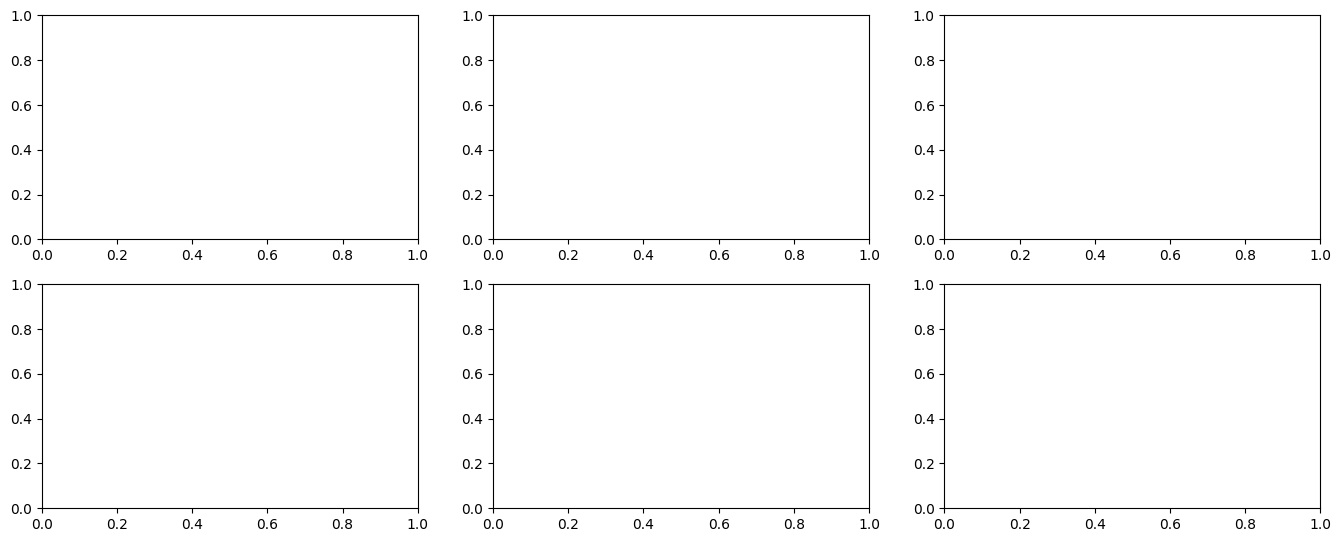

In [73]:
# AUC lives in the profile's eval snapshot, not in decoder_pipeline.joblib.
import joblib

eval_results = joblib.load(_profile.snapshot_paths["eval"])["_eval_results"]
auc_times = eval_results["times"]
auc_tasks = list(eval_results["tasks"].items())

ncols = 3
nrows = (len(auc_tasks) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.2 * nrows), squeeze=False)

for idx, (task, td) in enumerate(auc_tasks):
    ax = axes[idx // ncols][idx % ncols]
    c = plt.cm.tab10(idx % 10)
    ax.plot(auc_times, td["diagonal_auc"], color=c, lw=1.8)
    tp = task_tp(task)                        # this decoder's trained timepoint
    if tp is not None:
        ax.axvline(tp, color=c, ls=":", lw=1)
    ax.axhline(0.5, color="gray", ls="--", lw=0.8)
    ax.axvline(0.0, color="k", ls=":", lw=0.8)
    ax.set(title=f"{task}  (peak {td['peak_auc']:.3f})", ylim=(0.4, 1.0),
           xlabel="time (s)", ylabel="CV AUC")

for j in range(len(auc_tasks), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle(f"Cross-validated diagonal AUC per decoder \u2014 profile '{_profile.name}'", y=1.02)
plt.tight_layout(); plt.show()

print(f"average peak AUC across decoders: {eval_results['average_peak_auc']:.3f}"
      f"  |  suggested timepoint: {eval_results['suggested_timepoint']:.3f}s")

---
## Load the recording (replay-style channels) and marker positions

Channels are handled exactly like `scripts/replay_vhdr_to_lsl.build_stream_matrix`:
keep EEG-typed channels, drop `EMG` → 64 EEG channels. Marker positions use the
**real** trigger codes parsed from the BrainVision `Stimulus/S xx` annotations.

In [ ]:
def find_vhdr(d):
    vhdrs = list(Path(d).glob("*.vhdr"))
    if not vhdrs:
        raise FileNotFoundError(f"No .vhdr file found in {d}")
    return vhdrs[0]

# Lazy-load then crop when MAX_SECONDS is set so the full multi-hour buffer
# never lives in RAM (otherwise read_raw_brainvision(preload=True) needs ~1.6 GB
# for the 3267 s localizer recording).
_vhdr_path = find_vhdr(RECORDING_DIR)
if MAX_SECONDS is not None:
    raw = mne.io.read_raw_brainvision(_vhdr_path, preload=False, verbose=False)
    raw.crop(tmin=0.0, tmax=float(MAX_SECONDS))
    raw.load_data(verbose=False)
else:
    raw = mne.io.read_raw_brainvision(_vhdr_path, preload=True, verbose=False)
sfreq = float(raw.info["sfreq"])

# Replay-style channel handling: EEG-typed channels, EMG dropped -> 64 channels.
eeg_names = [raw.ch_names[i] for i in mne.pick_types(raw.info, eeg=True)]
if "EMG" in eeg_names:
    eeg_names.remove("EMG")
eeg = raw.copy().pick(eeg_names).get_data().T   # (n_times, 64), SI volts
n_times, n_fed = eeg.shape

if MAX_SECONDS is not None:
    print(f"[crop] first {MAX_SECONDS}s -> {n_times} samples")

print(f"sfreq={sfreq:g} Hz | fed EEG channels={n_fed} | "
      f"samples={n_times} ({n_times / sfreq:.1f}s)")

# Channel-alignment parity check (see GH issue on EMG / eeg_chunk_indices).
assert max(eci) < n_fed, (
    f"eeg_chunk_indices max index {max(eci)} >= fed channel count {n_fed}. "
    "EMG / channel alignment mismatch between offline (EMG-included) and the "
    "64-channel replay feed. See the GH issue."
)

# Marker sample positions with REAL trigger codes: parse 'Stimulus/S 11' -> 11.
desc_to_code = {}
for d in set(raw.annotations.description):
    m = re.search(r"(\d+)\s*$", d)
    if m:
        desc_to_code[d] = int(m.group(1))
events, _ = mne.events_from_annotations(raw, event_id=desc_to_code, verbose=False)

codes_of_interest = {event_mapping[n] for n in MARKERS_OF_INTEREST}
markers = [(int(s), int(c)) for s, _, c in events
           if c in codes_of_interest and s < n_times]   # (sample, code)
print("epochable markers:",
      {name_by_code[c]: n for c, n in Counter(c for _, c in markers).items()})

sfreq=1000 Hz | fed EEG channels=64 | samples=3267209 (3267.2s)
epochable markers: {'green': 70, 'red': 70, 'living_room': 70, 'bathroom': 70, 'kitchen': 70, 'yellow': 69}


---
## Diagnostic — marker timeline (block-structure check)

Are marker types **blocked** (each type clustered in its own time window) or
**interleaved** (every type spans the whole recording)? This tells us whether
the per-marker baseline offsets in the prediction plots are explained by slow
drift correlated with block, or by something deeper.

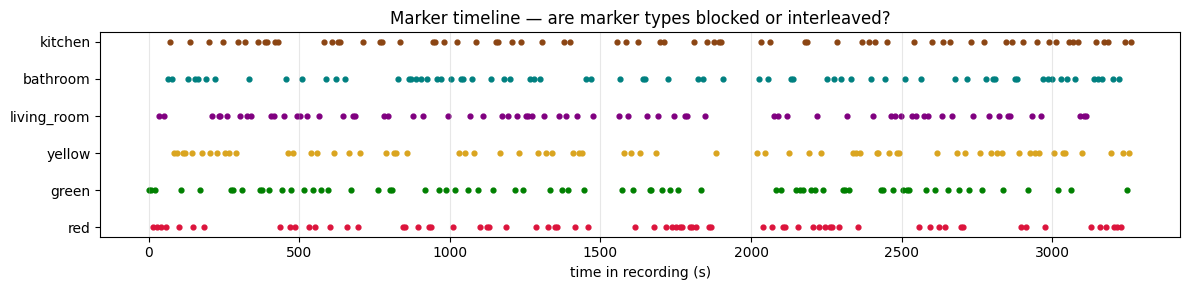

marker           first (s)    last (s)    span (s)    median ISI     n
--------------------------------------------------------------------------
red                   14.6      3227.6      3213.0         30.15    70
green                  2.0      3248.1      3246.1         34.50    70
yellow                85.6      3255.1      3169.4         30.63    69
living_room           34.6      3112.1      3077.5         34.92    70
bathroom              64.4      3220.2      3155.8         31.20    70
kitchen               71.0      3261.1      3190.1         40.81    70


In [ ]:
# Re-derive marker times from the FULL recording (ignore MAX_SECONDS) so the
# experiment's true layout is visible even on a cropped quick-run.
events_full, _ = mne.events_from_annotations(raw, event_id=desc_to_code, verbose=False)

marker_times_by_name = {}
for marker_name in MARKERS_OF_INTEREST:
    trigger_code = event_mapping[marker_name]
    marker_times_by_name[marker_name] = np.array(
        [sample_position / sfreq
         for sample_position, _, code in events_full
         if code == trigger_code]
    )

fig, ax = plt.subplots(figsize=(12, 3))
for marker_name, marker_times in marker_times_by_name.items():
    ax.scatter(marker_times, [marker_name] * len(marker_times),
               s=12, color=colors.get(marker_name) if "colors" in dir() else None)
ax.set_xlabel("time in recording (s)")
ax.set_title("Marker timeline — are marker types blocked or interleaved?")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

# Numeric summary: first / last / span / median ISI per marker type.
print(f"{'marker':<14}{'first (s)':>12}{'last (s)':>12}{'span (s)':>12}"
      f"{'median ISI':>14}{'n':>6}")
print("-" * 74)
for marker_name, marker_times in marker_times_by_name.items():
    if len(marker_times) == 0:
        continue
    median_isi = float(np.median(np.diff(marker_times))) if len(marker_times) > 1 else float("nan")
    print(f"{marker_name:<14}{marker_times.min():>12.1f}{marker_times.max():>12.1f}"
          f"{(marker_times.max() - marker_times.min()):>12.1f}"
          f"{median_isi:>14.2f}{len(marker_times):>6}")

---
## Run continuous live inference (micro-batched, persistent filter state)

`timestamps` carries the original sample index, so each 100 Hz output row maps back
to a raw sample — that mapping is what lets us epoch the prediction stream.

In [ ]:
preproc.reset_state()
sample_idx = np.arange(n_times)

feat_chunks, out_idx_chunks = [], []
for start in range(0, n_times, BATCH_SIZE_SAMPLES):
    sl = slice(start, start + BATCH_SIZE_SAMPLES)
    feats, out_ts = preproc.process_batch(eeg[sl], sample_idx[sl])
    if feats.shape[0]:
        feat_chunks.append(feats)
        out_idx_chunks.append(out_ts)

features    = np.vstack(feat_chunks)             # (n_out, n_channels) @ target rate
out_samples = np.concatenate(out_idx_chunks)     # original-sample index of each output row
preds       = engine.predict(features)           # {task: (n_out,)}
fs_out      = preproc.target_sfreq

print(f"output rows={features.shape[0]} @ {fs_out:g} Hz | tasks={list(preds.keys())}")

output rows=326721 @ 100 Hz | tasks=['red decoder', 'green decoder', 'yellow decoder', 'living_room decoder', 'bathroom decoder', 'kitchen decoder']


---
## Epoch the prediction stream by marker

Each marker's surrounding outputs are interpolated onto a common `[tmin, tmax]`
grid, giving `(n_epochs, n_times)` per task per marker.

In [ ]:
TMIN = prepro_settings["epochs"]["tmin"]
TMAX = prepro_settings["epochs"]["tmax"]
t_grid = np.arange(round(TMIN * fs_out), round(TMAX * fs_out) + 1) / fs_out

rel_time = out_samples / sfreq   # absolute output time in seconds

def epoch_stream(prob, marker_samples):
    rows = []
    for s in marker_samples:
        rt = rel_time - s / sfreq                       # output time relative to marker
        m = (rt >= TMIN - 0.05) & (rt <= TMAX + 0.05)
        if m.sum() < 2:
            continue
        rows.append(np.interp(t_grid, rt[m], prob[m]))
    return np.array(rows) if rows else np.empty((0, len(t_grid)))

epoched = {}   # epoched[task][marker_name] = (n_epochs, len(t_grid))
for task, prob in preds.items():
    epoched[task] = {}
    for name in MARKERS_OF_INTEREST:
        code_ = event_mapping[name]
        ms = [s for s, c in markers if c == code_]
        epoched[task][name] = epoch_stream(prob, ms)

# Epoch counts per marker (same for every task — driven by the markers, not the model).
print("epochs per marker:",
      {name: epoched[next(iter(preds))][name].shape[0] for name in MARKERS_OF_INTEREST})

epochs per marker: {'red': 70, 'green': 70, 'yellow': 69, 'living_room': 70, 'bathroom': 70, 'kitchen': 70}


---
## Individual epochs — every decoder on its own positive marker

One panel per decoder; each faint line is one trial's P(t) for that decoder's
target marker. Sanity: the mean (navy) should sit above 0.5 near the trained
timepoint if the decoder responds to its own stimulus.

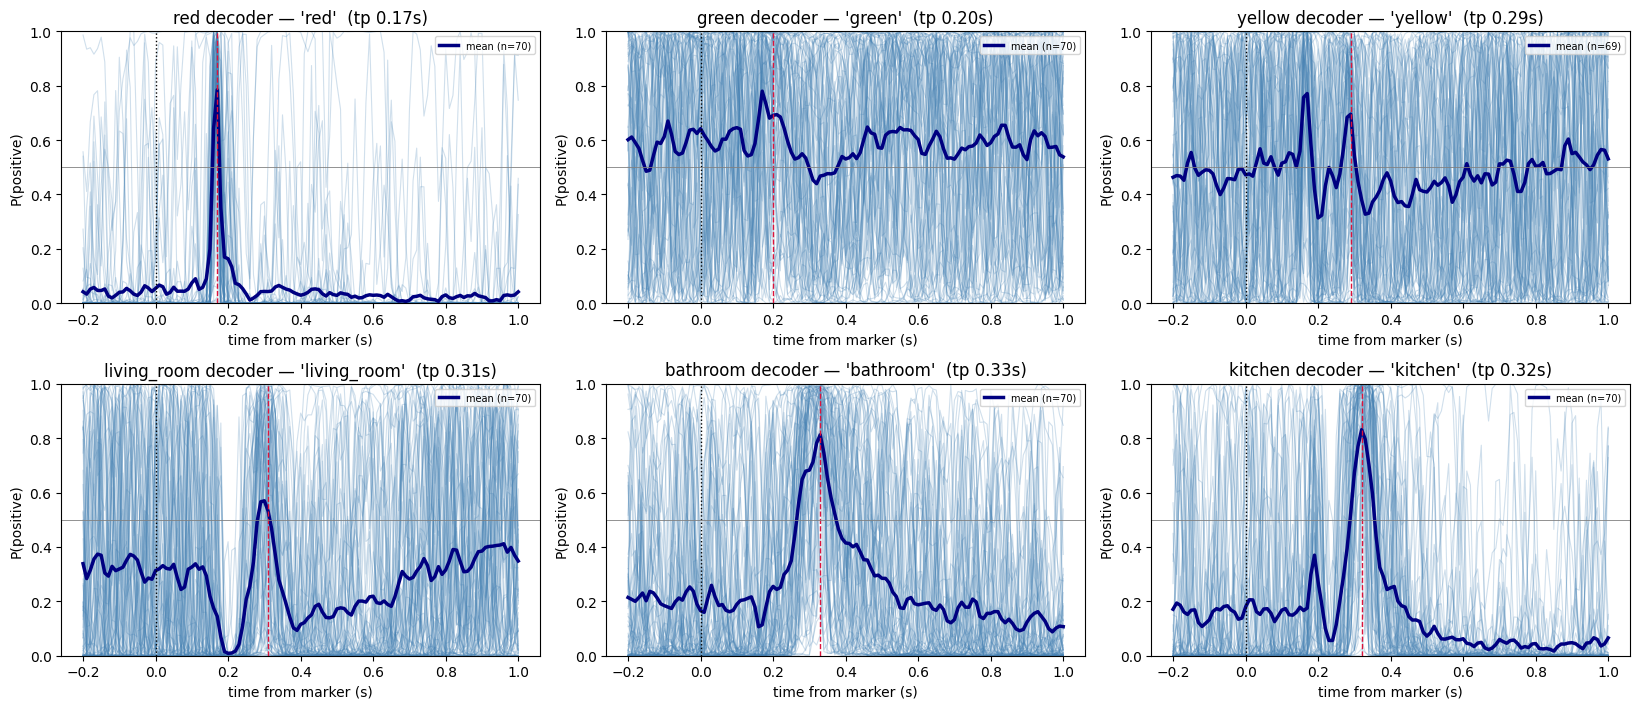

In [ ]:
task_names = list(preds.keys())
ncols = 3
nrows = (len(task_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows), squeeze=False)

for idx, task in enumerate(task_names):
    ax = axes[idx // ncols][idx % ncols]
    marker = task_pos_marker.get(task)
    ep = epoched.get(task, {}).get(marker, np.empty((0, len(t_grid))))
    for row in ep:
        ax.plot(t_grid, row, color="steelblue", alpha=0.25, lw=0.8)
    if ep.shape[0]:
        ax.plot(t_grid, ep.mean(0), color="navy", lw=2.5, label=f"mean (n={ep.shape[0]})")
    ax.axvline(0, color="k", ls=":", lw=1)
    tp = task_tp(task)                       # this decoder's own trained timepoint
    if tp is not None:
        ax.axvline(tp, color="crimson", ls="--", lw=1)
    ax.axhline(0.5, color="gray", lw=0.6)
    title = f"{task} — '{marker}'" + (f"  (tp {tp:.2f}s)" if tp is not None else "")
    ax.set(title=title, ylim=(0, 1),
           xlabel="time from marker (s)", ylabel="P(positive)")
    ax.legend(fontsize=7, loc="upper right")

for j in range(len(task_names), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Average prediction per marker — the "does it make sense?" view

One panel per decoder, all markers overlaid. For `"<x> decoder"`, expect the
`<x>` curve to rise and peak near the trained timepoint while the others stay
near chance.

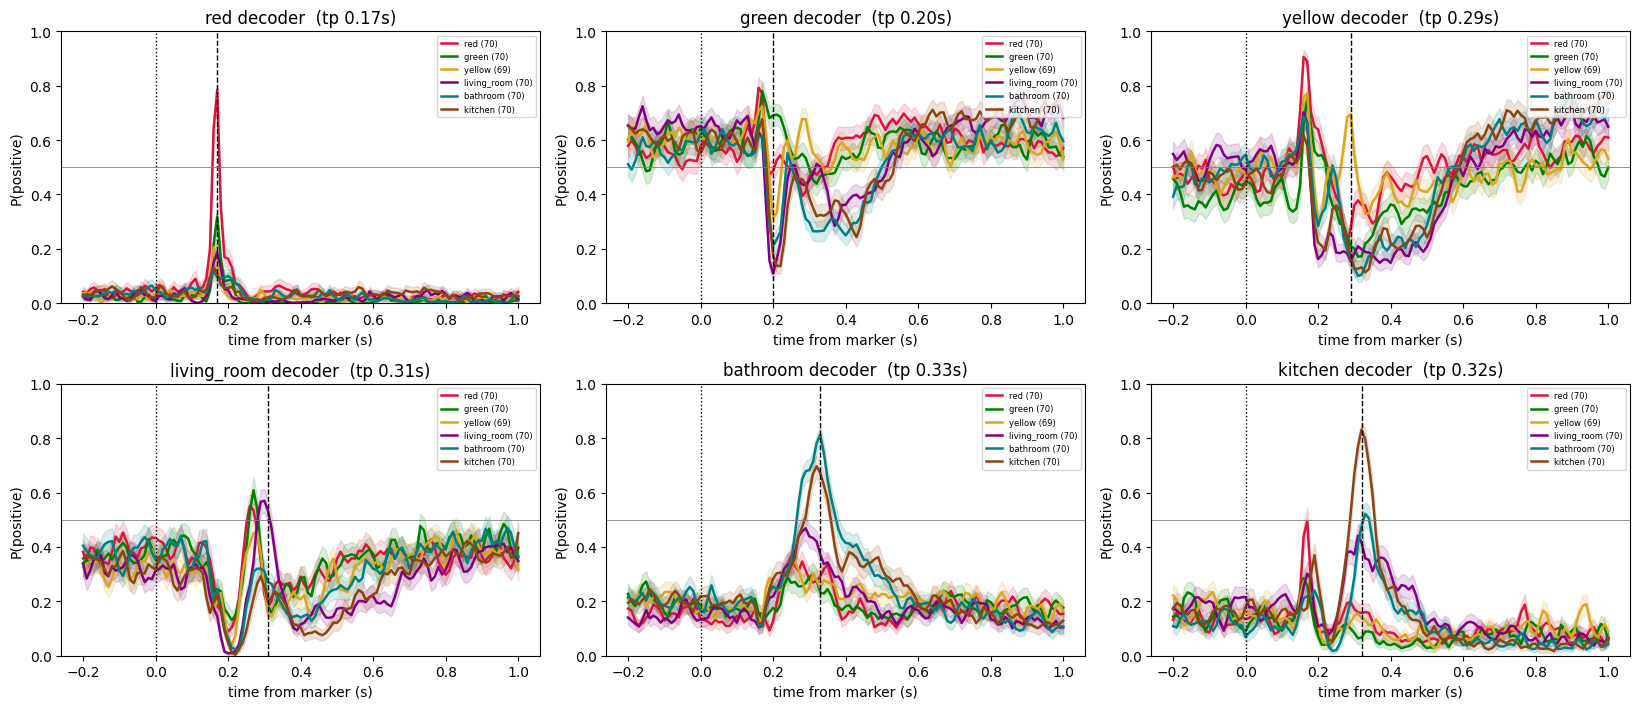

In [ ]:
colors = {"red": "crimson", "green": "green", "yellow": "goldenrod",
          "living_room": "purple", "bathroom": "teal", "kitchen": "saddlebrown"}

task_names = list(preds.keys())
ncols = 3
nrows = (len(task_names) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows), squeeze=False)

for idx, task in enumerate(task_names):
    ax = axes[idx // ncols][idx % ncols]
    for name in MARKERS_OF_INTEREST:
        ep = epoched[task][name]
        if ep.shape[0] == 0:
            continue
        mean = ep.mean(0)
        sem  = ep.std(0) / np.sqrt(ep.shape[0])
        c = colors.get(name)
        ax.plot(t_grid, mean, color=c, lw=1.8, label=f"{name} ({ep.shape[0]})")
        ax.fill_between(t_grid, mean - sem, mean + sem, color=c, alpha=0.15)
    ax.axvline(0, color="k", ls=":", lw=1)
    tp = task_tp(task)                       # this decoder's own trained timepoint
    if tp is not None:
        ax.axvline(tp, color="black", ls="--", lw=1)
    ax.axhline(0.5, color="gray", lw=0.6)
    title = task + (f"  (tp {tp:.2f}s)" if tp is not None else "")
    ax.set(title=title, ylim=(0, 1),
           xlabel="time from marker (s)", ylabel="P(positive)")
    ax.legend(fontsize=6, loc="upper right")

for j in range(len(task_names), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Decoder competition per marker

Transpose of the previous view: one panel per **marker**, with **every decoder's**
mean P(t) (± SEM for the matching one) overlaid. For marker `<x>`, the
`<x> decoder` is drawn bold with a ★ and should sit above the others near its
trained timepoint — the "which decoder fires for this stimulus?" view.

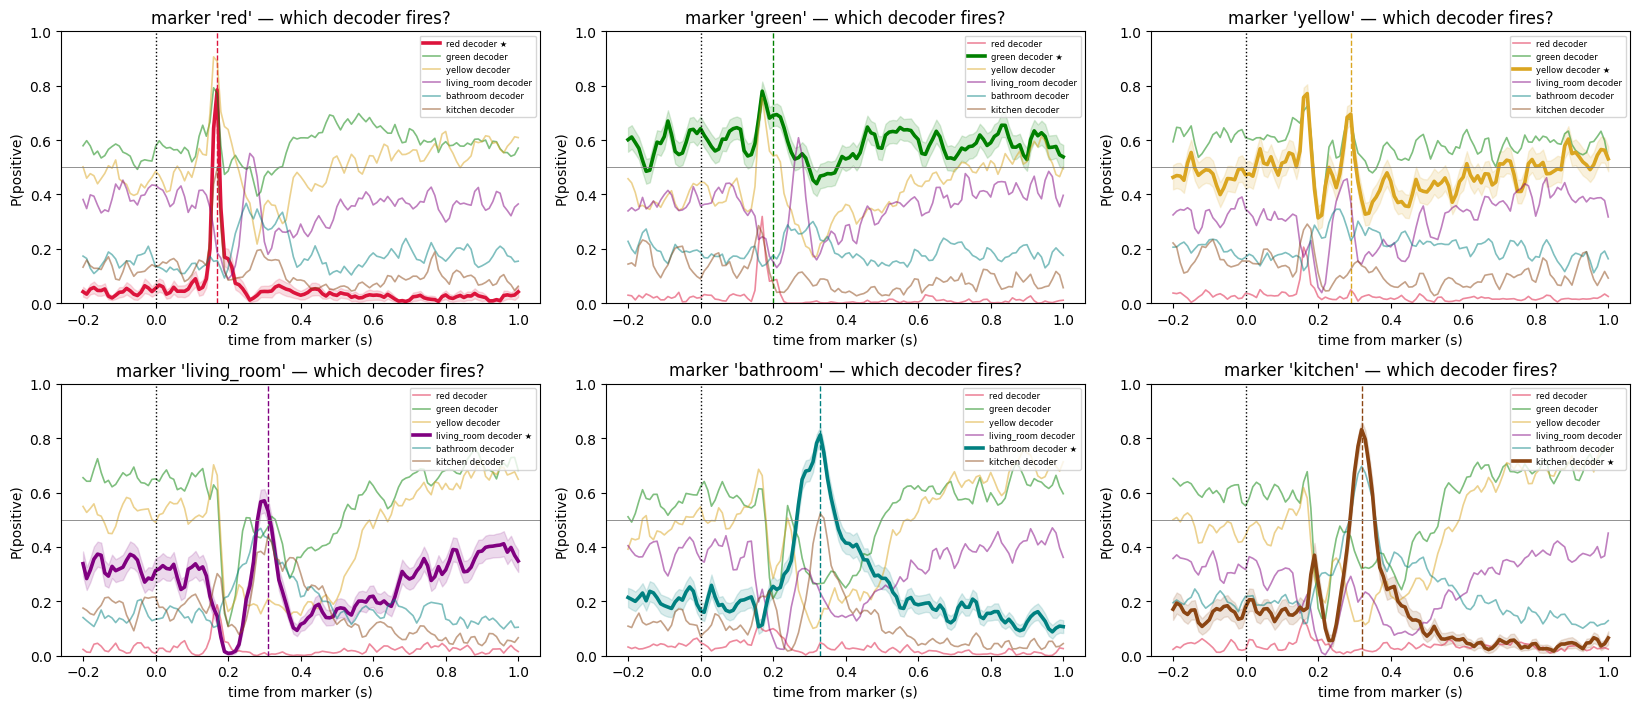

In [ ]:
# One panel per MARKER; every decoder's mean P(t) overlaid (averages across trials).
# Each decoder line is colored by its own target marker; the decoder whose target
# IS this panel's marker is bold + ★ and gets a ±SEM band.
task_names = list(preds.keys())
decoder_color = {task: colors.get(task_pos_marker.get(task)) for task in task_names}

ncols = 3
nrows = (len(MARKERS_OF_INTEREST) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows), squeeze=False)

for idx, marker in enumerate(MARKERS_OF_INTEREST):
    ax = axes[idx // ncols][idx % ncols]
    for task in task_names:
        ep = epoched[task][marker]
        if ep.shape[0] == 0:
            continue
        mean = ep.mean(0)
        is_target = (task_pos_marker.get(task) == marker)
        c = decoder_color.get(task)
        ax.plot(t_grid, mean, color=c,
                lw=2.6 if is_target else 1.2,
                alpha=1.0 if is_target else 0.5,
                label=(f"{task} \u2605" if is_target else task))
        if is_target:
            sem = ep.std(0) / np.sqrt(ep.shape[0])
            ax.fill_between(t_grid, mean - sem, mean + sem, color=c, alpha=0.15)
            tp = task_tp(task)                 # mark the winning decoder's trained tp
            if tp is not None:
                ax.axvline(tp, color=c, ls="--", lw=1)
    ax.axvline(0, color="k", ls=":", lw=1)
    ax.axhline(0.5, color="gray", lw=0.6)
    ax.set(title=f"marker '{marker}' \u2014 which decoder fires?", ylim=(0, 1),
           xlabel="time from marker (s)", ylabel="P(positive)")
    ax.legend(fontsize=6, loc="upper right")

for j in range(len(MARKERS_OF_INTEREST), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
plt.tight_layout(); plt.show()

---
## Quick summary at the trained timepoint

Mean P(positive) per decoder × marker. The diagonal (decoder vs its own marker)
should be the largest entry in each row if the decoders are sensible.

In [ ]:
# Each decoder is sampled at ITS OWN trained timepoint (per-task if the artifact
# has decoding_timepoints, else the shared decoding_timepoint). The diagonal
# (decoder vs its own marker) should be the largest entry in each row.
if default_tp is not None or tp_by_task:
    w = max(9, max(len(n) for n in MARKERS_OF_INTEREST) + 1)
    print("Mean P(positive), each decoder at its own trained timepoint:\n")
    header = "task".ljust(22) + "tp(s)".rjust(8) + "".join(n.rjust(w) for n in MARKERS_OF_INTEREST)
    print(header)
    print("-" * len(header))
    for task in preds:
        tp = task_tp(task)
        if tp is None:
            continue
        ti = int(np.argmin(np.abs(t_grid - tp)))
        row = task.ljust(22) + f"{t_grid[ti]:.2f}".rjust(8)
        for name in MARKERS_OF_INTEREST:
            ep = epoched[task][name]
            row += (f"{ep[:, ti].mean():.3f}" if ep.shape[0] else "n/a").rjust(w)
        print(row)
else:
    print("No trained timepoint in metadata; skipping summary.")

Mean P(positive), each decoder at its own trained timepoint:

task                     tp(s)         red       green      yellow living_room    bathroom     kitchen
------------------------------------------------------------------------------------------------------
red decoder               0.17       0.785       0.319       0.171       0.187       0.096       0.109
green decoder             0.20       0.486       0.691       0.312       0.109       0.210       0.175
yellow decoder            0.29       0.276       0.210       0.696       0.154       0.165       0.174
living_room decoder       0.31       0.180       0.179       0.154       0.533       0.270       0.197
bathroom decoder          0.33       0.291       0.233       0.250       0.373       0.812       0.673
kitchen decoder           0.32       0.157       0.067       0.138       0.416       0.477       0.832


---
## Save results for this profile (for later cross-profile comparison)

Writes a compact `debug_snapshots/<PROFILE>/live_summary.joblib`: the inference
P(t) **means/SEM** per decoder x marker (not per-epoch), the per-decoder-timepoint
diagonal table, and the CV AUC bundled in. A separate comparison notebook can
load several profiles' summaries and overlay them.

In [ ]:
import joblib

# Mean / SEM inference trajectories per decoder x marker (compact: no per-epoch rows).
pt_mean, pt_sem = {}, {}
for task in preds:
    pt_mean[task], pt_sem[task] = {}, {}
    for m in MARKERS_OF_INTEREST:
        ep = epoched[task][m]
        if ep.shape[0]:
            pt_mean[task][m] = ep.mean(0)
            pt_sem[task][m]  = ep.std(0) / np.sqrt(ep.shape[0])
        else:
            pt_mean[task][m] = pt_sem[task][m] = None

# Headline table: each decoder sampled at its OWN trained timepoint.
diag_at_tp = {}
for task in preds:
    tp = task_tp(task)
    ti = int(np.argmin(np.abs(t_grid - tp))) if tp is not None else None
    diag_at_tp[task] = {
        m: (float(epoched[task][m][:, ti].mean()) if (ti is not None and epoched[task][m].shape[0]) else None)
        for m in MARKERS_OF_INTEREST
    }

summary = {
    "profile": _profile.name,
    "max_seconds": MAX_SECONDS,
    "markers": list(MARKERS_OF_INTEREST),
    "tasks": list(preds.keys()),
    "task_pos_marker": {t: task_pos_marker.get(t) for t in preds},
    "tp_by_task": {t: task_tp(t) for t in preds},
    "t_grid": t_grid,
    "pt_mean": pt_mean,
    "pt_sem": pt_sem,
    "diag_at_tp": diag_at_tp,
    "n_epochs": {m: int(epoched[next(iter(preds))][m].shape[0]) for m in MARKERS_OF_INTEREST},
    # CV AUC (from eval snapshot) bundled so a comparison can read one file.
    "auc_times": eval_results["times"],
    "diagonal_auc": {t: td["diagonal_auc"] for t, td in eval_results["tasks"].items()},
    "peak_auc": {t: float(td["peak_auc"]) for t, td in eval_results["tasks"].items()},
    "average_peak_auc": float(eval_results["average_peak_auc"]),
    "suggested_timepoint": float(eval_results["suggested_timepoint"]),
}

out_path = _profile.root_dir / "live_summary.joblib"
joblib.dump(summary, out_path)
print("saved", out_path)
print("  decoders:", len(summary["tasks"]), "| markers:", len(summary["markers"]),
      "| avg peak AUC:", round(summary["average_peak_auc"], 3))

saved /home/itaip/projects/live-reactivation-decoder/debug_snapshots/fl_logistic_l1/live_summary.joblib
  decoders: 6 | markers: 6 | avg peak AUC: 0.779
